
# 14 - OLS geographic placebos and sensitivity

This notebook studies whether the geographic signal is substantive or fragile.

Question:

> Is the apparent geographic signal robust, or can it be reproduced by rank/placebo encodings or by changing household-pyramid controls?

Experiments compared:

1. `ols_core`
2. `ols_core_geo_ranks`
3. `ols_core_shuffled_geo_ranks`
4. `ols_core_aglo_fe`
5. `ols_core_aglo_fe_no_pyramid`

Main diagnostics:

- real geographic ranks vs shuffled geographic ranks
- agglomerate FE with vs without household pyramid controls
- changes in fit metrics
- changes in agglomerate residual variance
- changes in agglomerate residual-effect ranking


## 00. Setup and run discovery

In [1]:

from pathlib import Path
import json
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/home/matias/repos/income-modeling-eph"),
]

ROOT = next(
    (p for p in ROOT_CANDIDATES if (p / "reports" / "runs").exists()),
    Path("/home/matias/repos/income-modeling-eph"),
)

RUNS_DIR = ROOT / "reports" / "runs"
DATASET_PATH = ROOT / "data" / "processed" / "modeling_dataset.parquet"

OUTPUT_DIR = ROOT / "reports" / "notebook_outputs" / "ols_geo_placebos_and_sensitivity"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 160)

print("ROOT:", ROOT)
print("RUNS_DIR:", RUNS_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


def read_json_if_exists(path: Path):
    if not path.exists():
        return None
    return json.loads(path.read_text())


def read_yaml_if_exists(path: Path):
    if not path.exists():
        return None
    return yaml.safe_load(path.read_text())


def read_csv_if_exists(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def read_parquet_if_exists(path: Path) -> pd.DataFrame:
    return pd.read_parquet(path) if path.exists() else pd.DataFrame()


RUN_PATTERNS = {
    "ols_core": "ols_core_*",
    "ols_core_geo_ranks": "ols_core_geo_ranks_*",
    "ols_core_shuffled_geo_ranks": "ols_core_shuffled_geo_ranks_*",
    "ols_core_aglo_fe": "ols_core_aglo_fe_*",
    "ols_core_aglo_fe_no_pyramid": "ols_core_aglo_fe_no_pyramid_*",
}

ORDER = [
    "ols_core",
    "ols_core_geo_ranks",
    "ols_core_shuffled_geo_ranks",
    "ols_core_aglo_fe",
    "ols_core_aglo_fe_no_pyramid",
]

DISPLAY_LABELS = {
    "ols_core": "Core OLS",
    "ols_core_geo_ranks": "+ Real geo ranks",
    "ols_core_shuffled_geo_ranks": "+ Shuffled geo ranks",
    "ols_core_aglo_fe": "+ Aglomerado FE",
    "ols_core_aglo_fe_no_pyramid": "+ Aglomerado FE, no pyramid",
}


def discover_runs() -> dict[str, Path | None]:
    runs = {}
    for experiment, pattern in RUN_PATTERNS.items():
        candidates = sorted(RUNS_DIR.glob(pattern), key=lambda p: p.name)
        if not candidates:
            runs[experiment] = None
            continue

        exact = []
        for candidate in candidates:
            config = read_yaml_if_exists(candidate / "config_used.yaml") or {}
            experiment_id = ((config.get("experiment") or {}).get("id"))
            if experiment_id == experiment:
                exact.append(candidate)

        runs[experiment] = exact[-1] if exact else candidates[-1]
    return runs


RUNS = discover_runs()

run_table = pd.DataFrame(
    [
        {"experiment": exp, "run_dir": str(path) if path else None, "found": path is not None}
        for exp, path in RUNS.items()
    ]
)

run_table


ROOT: /home/matias/repos/income-modeling-eph
RUNS_DIR: /home/matias/repos/income-modeling-eph/reports/runs
OUTPUT_DIR: /home/matias/repos/income-modeling-eph/reports/notebook_outputs/ols_geo_placebos_and_sensitivity


,experiment,run_dir,found
0,ols_core,/home/matias/repos/income-modeling-eph/reports...,True
1,ols_core_geo_ranks,/home/matias/repos/income-modeling-eph/reports...,True
2,ols_core_shuffled_geo_ranks,/home/matias/repos/income-modeling-eph/reports...,True
3,ols_core_aglo_fe,/home/matias/repos/income-modeling-eph/reports...,True
4,ols_core_aglo_fe_no_pyramid,/home/matias/repos/income-modeling-eph/reports...,True


## 01. Load backend artifacts

In [2]:

def load_model_comparison(run_dir: Path, experiment: str) -> pd.DataFrame:
    df = read_csv_if_exists(run_dir / "metrics" / "model_comparison.csv")
    if df.empty:
        return df
    df["experiment"] = experiment
    df["run_dir"] = str(run_dir)
    return df


def load_predictions(run_dir: Path, experiment: str, split: str) -> pd.DataFrame:
    path = run_dir / "predictions" / f"{split}_predictions.parquet"
    df = read_parquet_if_exists(path)
    if df.empty:
        return df

    df["experiment"] = experiment
    df["run_dir"] = str(run_dir)
    df["split"] = split

    if "residual" not in df.columns:
        df["residual"] = df["y_true"] - df["y_pred"]
    if "abs_error" not in df.columns:
        df["abs_error"] = df["residual"].abs()
    if "squared_error" not in df.columns:
        df["squared_error"] = df["residual"] ** 2

    return df


def load_run_metadata(run_dir: Path, experiment: str) -> dict:
    feature_columns = read_json_if_exists(run_dir / "feature_columns.json") or []
    dataset_card = read_json_if_exists(run_dir / "dataset_card.json") or {}
    config_used = read_yaml_if_exists(run_dir / "config_used.yaml") or {}
    feature_view = config_used.get("feature_view") or {}
    fixed_effects = (config_used.get("model_design") or {}).get("fixed_effects") or []

    return {
        "experiment": experiment,
        "run_dir": str(run_dir),
        "n_feature_columns": len(feature_columns),
        "feature_columns": feature_columns,
        "feature_view_name": feature_view.get("name"),
        "include_blocks": feature_view.get("include_blocks"),
        "permute_group_values": feature_view.get("permute_group_values"),
        "fixed_effects_config": fixed_effects,
        "dataset_card": dataset_card,
        "config_used": config_used,
    }


model_comparison_parts = []
prediction_parts = []
metadata_rows = []

for experiment, run_dir in RUNS.items():
    if run_dir is None:
        continue
    model_comparison_parts.append(load_model_comparison(run_dir, experiment))
    for split in ["validation", "test"]:
        prediction_parts.append(load_predictions(run_dir, experiment, split))
    metadata_rows.append(load_run_metadata(run_dir, experiment))

model_comparison = (
    pd.concat([d for d in model_comparison_parts if not d.empty], ignore_index=True)
    if any(not d.empty for d in model_comparison_parts)
    else pd.DataFrame()
)

predictions = (
    pd.concat([d for d in prediction_parts if not d.empty], ignore_index=True)
    if any(not d.empty for d in prediction_parts)
    else pd.DataFrame()
)

run_metadata = pd.DataFrame(metadata_rows)

print("model_comparison:", model_comparison.shape)
print("predictions:", predictions.shape)
print("run_metadata:", run_metadata.shape)

run_metadata[[
    "experiment", "feature_view_name", "include_blocks", 
    "permute_group_values", "fixed_effects_config", "n_feature_columns"
]]


model_comparison: (5, 14)
predictions: (300000, 12)
run_metadata: (5, 10)


,experiment,feature_view_name,include_blocks,permute_group_values,fixed_effects_config,n_feature_columns
0,ols_core,linear_core,"[demographic, education, labor, housing_househ...",None,[],28
1,ols_core_geo_ranks,linear_core_geo_ranks,"[demographic, education, labor, housing_househ...",None,[],30
2,ols_core_shuffled_geo_ranks,linear_core_shuffled_geo_ranks,"[demographic, education, labor, housing_househ...","[{'column': 'AGLO_rk', 'group_by': 'AGLOMERADO...",[],30
3,ols_core_aglo_fe,linear_core_aglo_fe,"[demographic, education, labor, housing_househ...",None,"[{'name': 'aglo_fe', 'columns': ['AGLOMERADO']...",29
4,ols_core_aglo_fe_no_pyramid,linear_core_aglo_fe_no_pyramid,"[demographic, education, labor, housing_househ...",None,"[{'name': 'aglo_fe', 'columns': ['AGLOMERADO']...",22


## 02. Enrich predictions with geography

In [3]:

if predictions.empty:
    raise RuntimeError(
        "No predictions were loaded. Run the OLS geo placebo/sensitivity experiments first or check RUN_PATTERNS."
    )

geo_cols = ["row_id", "Region", "AGLOMERADO", "AGLO_rk", "Reg_rk", "ANO4", "TRIMESTRE"]
if DATASET_PATH.exists():
    dataset_geo = pd.read_parquet(DATASET_PATH, columns=geo_cols)
else:
    raise FileNotFoundError(f"Processed dataset not found: {DATASET_PATH}")

pred_geo = predictions.merge(dataset_geo, on="row_id", how="left", validate="many_to_one")

for col in ["Region", "AGLOMERADO", "ANO4", "TRIMESTRE"]:
    pred_geo[col] = pred_geo[col].astype("string")

pred_geo.head()


,run_id,model,split,row_id,y_true,y_pred,residual,abs_error,squared_error,income_decile,experiment,run_dir,Region,AGLOMERADO,AGLO_rk,Reg_rk,ANO4,TRIMESTRE
0,ols_core_20260611T050750Z,LinearRegression,validation,0,3.484442,3.554492,-0.070050,0.070050,0.004907,3,ols_core,/home/matias/repos/income-modeling-eph/reports...,Noroeste,23,0.394,0.333,2022,3
1,ols_core_20260611T050750Z,LinearRegression,validation,26,3.735759,3.783123,-0.047365,0.047365,0.002243,6,ols_core,/home/matias/repos/income-modeling-eph/reports...,Noroeste,0,0.545,0.333,2022,4
2,ols_core_20260611T050750Z,LinearRegression,validation,32,3.680789,3.504383,0.176406,0.176406,0.031119,6,ols_core,/home/matias/repos/income-modeling-eph/reports...,Gran Buenos Aires,33,0.727,0.833,2022,1
3,ols_core_20260611T050750Z,LinearRegression,validation,36,3.525822,3.553849,-0.028027,0.028027,0.000786,4,ols_core,/home/matias/repos/income-modeling-eph/reports...,Pampeana,13,0.455,0.667,2022,1
4,ols_core_20260611T050750Z,LinearRegression,validation,56,3.856850,3.697136,0.159713,0.159713,0.025508,8,ols_core,/home/matias/repos/income-modeling-eph/reports...,Noreste,8,0.061,0.167,2022,1


## 03. Aggregate metrics

In [4]:

def safe_r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) == 0:
        return np.nan
    denom = np.sum((y_true - y_true.mean()) ** 2)
    if denom == 0:
        return np.nan
    return 1 - np.sum((y_true - y_pred) ** 2) / denom


def aggregate_metrics(g):
    y = g["y_true"].astype(float)
    yhat = g["y_pred"].astype(float)
    residual = y - yhat
    return pd.Series({
        "n": len(g),
        "r2": safe_r2(y, yhat),
        "mae": residual.abs().mean(),
        "rmse": np.sqrt((residual ** 2).mean()),
        "mean_error": (yhat - y).mean(),
        "sd_y_true": y.std(),
        "sd_y_pred": yhat.std(),
        "compression_ratio": yhat.std() / y.std() if y.std() else np.nan,
    })


metrics_by_split = (
    pred_geo
    .groupby(["experiment", "split"], as_index=False)
    .apply(aggregate_metrics, include_groups=False)
    .reset_index(drop=True)
)

metrics_by_split["experiment_order"] = metrics_by_split["experiment"].map({exp: i for i, exp in enumerate(ORDER)})
metrics_by_split["label"] = metrics_by_split["experiment"].map(DISPLAY_LABELS)

validation_summary = (
    metrics_by_split
    .query("split == 'validation'")
    .sort_values("experiment_order")
    .reset_index(drop=True)
)

core = validation_summary.query("experiment == 'ols_core'")
if not core.empty:
    core = core.iloc[0]
    for col in ["r2", "mae", "rmse", "compression_ratio"]:
        validation_summary[f"delta_{col}_vs_core"] = validation_summary[col] - core[col]

# Pair-specific deltas
def pair_delta(df, a, b, metric):
    rows = df.set_index("experiment")
    if a not in rows.index or b not in rows.index:
        return np.nan
    return rows.loc[a, metric] - rows.loc[b, metric]

pairwise_checks = pd.DataFrame([
    {
        "comparison": "real_geo_ranks_minus_shuffled_geo_ranks",
        "metric": metric,
        "delta": pair_delta(validation_summary, "ols_core_geo_ranks", "ols_core_shuffled_geo_ranks", metric),
    }
    for metric in ["r2", "mae", "rmse", "compression_ratio"]
] + [
    {
        "comparison": "aglo_fe_minus_aglo_fe_no_pyramid",
        "metric": metric,
        "delta": pair_delta(validation_summary, "ols_core_aglo_fe", "ols_core_aglo_fe_no_pyramid", metric),
    }
    for metric in ["r2", "mae", "rmse", "compression_ratio"]
])

metrics_by_split.to_csv(TABLE_DIR / "T1_ols_geo_placebo_metrics_by_split.csv", index=False)
validation_summary.to_csv(TABLE_DIR / "T2_ols_geo_placebo_validation_summary.csv", index=False)
pairwise_checks.to_csv(TABLE_DIR / "T3_ols_geo_placebo_pairwise_checks.csv", index=False)
run_metadata.to_csv(TABLE_DIR / "T4_ols_geo_placebo_run_metadata.csv", index=False)

display(validation_summary[[
    "experiment", "label", "n", "r2", "delta_r2_vs_core",
    "mae", "delta_mae_vs_core", "rmse", "delta_rmse_vs_core",
    "compression_ratio", "delta_compression_ratio_vs_core"
]].round(5))

display(pairwise_checks.pivot(index="comparison", columns="metric", values="delta").round(6))


,experiment,label,n,r2,delta_r2_vs_core,mae,delta_mae_vs_core,rmse,delta_rmse_vs_core,compression_ratio,delta_compression_ratio_vs_core
0,ols_core,Core OLS,20000.0,0.40193,0.00000,0.21663,0.00000,0.29189,0.00000,0.62909,0.00000
1,ols_core_geo_ranks,+ Real geo ranks,20000.0,0.41251,0.01058,0.21414,-0.00249,0.28930,-0.00259,0.63805,0.00896
2,ols_core_shuffled_geo_ranks,+ Shuffled geo ranks,20000.0,0.40219,0.00026,0.21658,-0.00005,0.29183,-0.00006,0.62936,0.00027
3,ols_core_aglo_fe,+ Aglomerado FE,20000.0,0.41547,0.01354,0.21370,-0.00293,0.28857,-0.00332,0.64175,0.01267
4,ols_core_aglo_fe_no_pyramid,"+ Aglomerado FE, no pyramid",20000.0,0.40672,0.00479,0.21550,-0.00113,0.29072,-0.00117,0.63547,0.00639


metric,compression_ratio,mae,r2,rmse
comparison,,,,
aglo_fe_minus_aglo_fe_no_pyramid,0.006282,-0.001799,0.008747,-0.002151
real_geo_ranks_minus_shuffled_geo_ranks,0.008688,-0.002439,0.010318,-0.002529


## 04. Figure 1 — real vs shuffled geo ranks

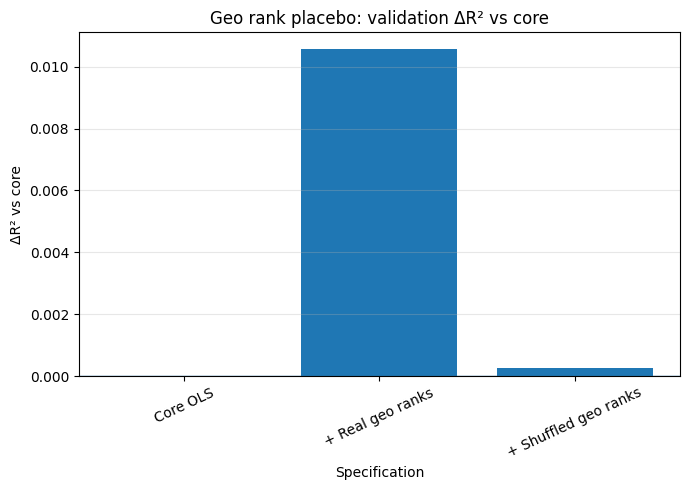

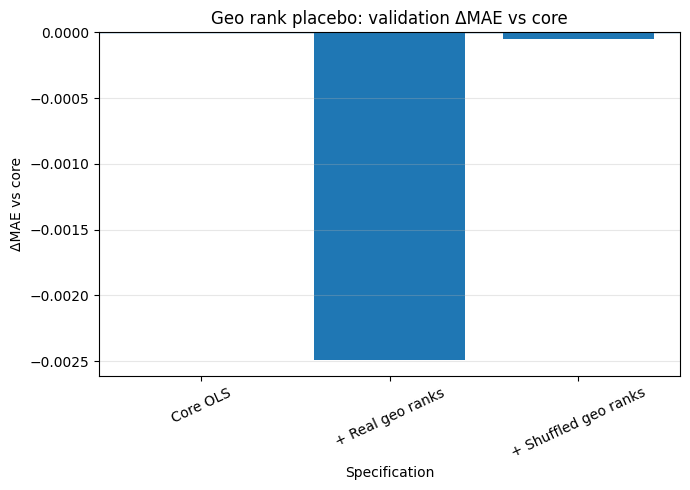

In [5]:

rank_df = validation_summary.query("experiment in ['ols_core', 'ols_core_geo_ranks', 'ols_core_shuffled_geo_ranks']").copy()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(rank_df["label"], rank_df["delta_r2_vs_core"])
ax.axhline(0, linewidth=1)
ax.set_title("Geo rank placebo: validation ΔR² vs core")
ax.set_xlabel("Specification")
ax.set_ylabel("ΔR² vs core")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "F1_ols_geo_ranks_real_vs_shuffled_delta_r2.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(rank_df["label"], rank_df["delta_mae_vs_core"])
ax.axhline(0, linewidth=1)
ax.set_title("Geo rank placebo: validation ΔMAE vs core")
ax.set_xlabel("Specification")
ax.set_ylabel("ΔMAE vs core")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "F2_ols_geo_ranks_real_vs_shuffled_delta_mae.png", dpi=160)
plt.show()


## 05. Figure 2 — aglo FE with vs without household pyramid

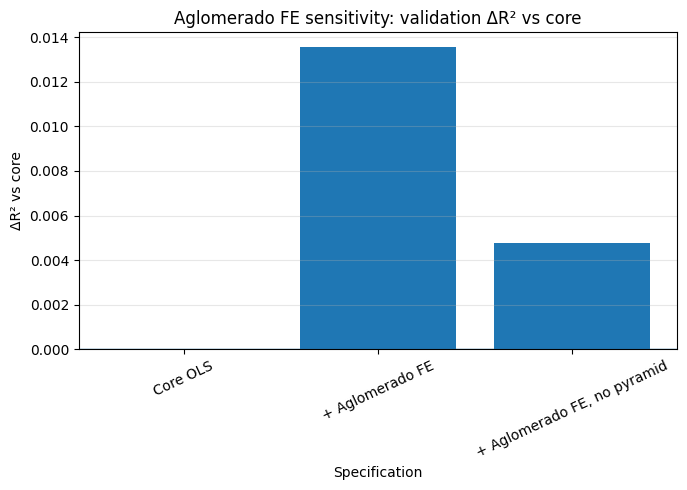

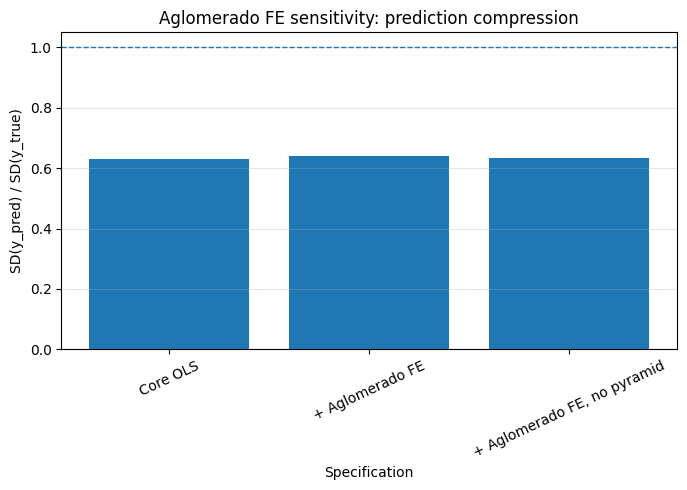

In [6]:

pyramid_df = validation_summary.query("experiment in ['ols_core', 'ols_core_aglo_fe', 'ols_core_aglo_fe_no_pyramid']").copy()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(pyramid_df["label"], pyramid_df["delta_r2_vs_core"])
ax.axhline(0, linewidth=1)
ax.set_title("Aglomerado FE sensitivity: validation ΔR² vs core")
ax.set_xlabel("Specification")
ax.set_ylabel("ΔR² vs core")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "F3_ols_aglo_fe_no_pyramid_delta_r2.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(pyramid_df["label"], pyramid_df["compression_ratio"])
ax.axhline(1, linestyle="--", linewidth=1)
ax.set_title("Aglomerado FE sensitivity: prediction compression")
ax.set_xlabel("Specification")
ax.set_ylabel("SD(y_pred) / SD(y_true)")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "F4_ols_aglo_fe_no_pyramid_compression.png", dpi=160)
plt.show()


## 06. Group residual summaries

In [7]:

def group_residual_summary(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    return (
        df
        .dropna(subset=[group_col])
        .groupby(["experiment", "split", group_col], as_index=False)
        .agg(
            n=("row_id", "size"),
            mean_y_true=("y_true", "mean"),
            mean_y_pred=("y_pred", "mean"),
            mean_residual=("residual", "mean"),
            sd_residual=("residual", "std"),
            mae=("abs_error", "mean"),
            rmse=("squared_error", lambda s: np.sqrt(np.mean(s))),
        )
        .rename(columns={group_col: "group_value"})
        .assign(group_type=group_col)
    )

region_residual_summary = group_residual_summary(pred_geo, "Region")
aglo_residual_summary = group_residual_summary(pred_geo, "AGLOMERADO")

group_residuals = pd.concat([region_residual_summary, aglo_residual_summary], ignore_index=True)
group_residuals["abs_mean_residual"] = group_residuals["mean_residual"].abs()

group_residuals.to_csv(TABLE_DIR / "T5_ols_geo_placebo_group_residuals.csv", index=False)

group_residuals.query("split == 'validation' and group_type == 'AGLOMERADO'").head()


,experiment,split,group_value,n,mean_y_true,mean_y_pred,mean_residual,sd_residual,mae,rmse,group_type,abs_mean_residual
93,ols_core,validation,0,973,3.641986,3.646607,-0.004622,0.305457,0.220837,0.305335,AGLOMERADO,0.004622
94,ols_core,validation,10,736,3.625449,3.653867,-0.028419,0.295428,0.216203,0.296592,AGLOMERADO,0.028419
95,ols_core,validation,12,526,3.546887,3.586834,-0.039946,0.315101,0.232664,0.317325,AGLOMERADO,0.039946
96,ols_core,validation,13,1054,3.676712,3.670994,0.005717,0.282697,0.207242,0.282621,AGLOMERADO,0.005717
97,ols_core,validation,14,475,3.558304,3.567844,-0.009540,0.266331,0.198079,0.266221,AGLOMERADO,0.009540


## 07. Geographic residual variance decomposition

In [8]:

def weighted_var(x, w=None):
    x = np.asarray(x, dtype=float)
    if w is None:
        mask = np.isfinite(x)
        return float(np.nanvar(x[mask])) if mask.any() else np.nan
    w = np.asarray(w, dtype=float)
    mask = np.isfinite(x) & np.isfinite(w)
    if mask.sum() == 0 or w[mask].sum() == 0:
        return np.nan
    mu = np.average(x[mask], weights=w[mask])
    return float(np.average((x[mask] - mu) ** 2, weights=w[mask]))


rows = []
for (experiment, split, group_type), df_g in group_residuals.groupby(["experiment", "split", "group_type"]):
    df_obs = pred_geo.query("experiment == @experiment and split == @split").copy()
    group_col = group_type
    if group_col not in df_obs.columns:
        continue

    effect_map = df_g.set_index("group_value")["mean_residual"]
    df_obs["group_mean_residual"] = df_obs[group_col].map(effect_map)

    var_y = weighted_var(df_obs["y_true"])
    var_pred = weighted_var(df_obs["y_pred"])
    var_resid = weighted_var(df_obs["residual"])
    var_group = weighted_var(df_obs["group_mean_residual"])

    rows.append({
        "experiment": experiment,
        "split": split,
        "group_type": group_type,
        "var_y": var_y,
        "var_pred": var_pred,
        "var_residual": var_resid,
        "var_group_mean_residual": var_group,
        "sd_y": np.sqrt(var_y),
        "sd_residual": np.sqrt(var_resid),
        "sd_group_mean_residual": np.sqrt(var_group),
        "share_var_y": var_group / var_y if var_y else np.nan,
        "share_var_residual": var_group / var_resid if var_resid else np.nan,
        "share_var_y_pct": 100 * var_group / var_y if var_y else np.nan,
        "share_var_residual_pct": 100 * var_group / var_resid if var_resid else np.nan,
    })

geo_variance_decomposition = pd.DataFrame(rows)
geo_variance_decomposition["experiment_order"] = geo_variance_decomposition["experiment"].map({exp: i for i, exp in enumerate(ORDER)})
geo_variance_decomposition["label"] = geo_variance_decomposition["experiment"].map(DISPLAY_LABELS)

geo_variance_decomposition.to_csv(TABLE_DIR / "T6_ols_geo_placebo_variance_decomposition.csv", index=False)

geo_variance_decomposition.query("split == 'validation'").sort_values(
    ["group_type", "share_var_y_pct"], ascending=[True, False]
).round(5)


,experiment,split,group_type,var_y,var_pred,var_residual,var_group_mean_residual,sd_y,sd_residual,sd_group_mean_residual,share_var_y,share_var_residual,share_var_y_pct,share_var_residual_pct,experiment_order,label
2,ols_core,validation,AGLOMERADO,0.14246,0.05638,0.08519,0.00166,0.37744,0.29188,0.04069,0.01162,0.01943,1.16203,1.94315,0,Core OLS
18,ols_core_shuffled_geo_ranks,validation,AGLOMERADO,0.14246,0.05643,0.08516,0.00161,0.37744,0.29181,0.04019,0.01134,0.01897,1.13365,1.89652,2,+ Shuffled geo ranks
14,ols_core_geo_ranks,validation,AGLOMERADO,0.14246,0.05800,0.08368,0.00059,0.37744,0.28928,0.02419,0.00411,0.00699,0.41065,0.69906,1,+ Real geo ranks
10,ols_core_aglo_fe_no_pyramid,validation,AGLOMERADO,0.14246,0.05753,0.08451,0.00014,0.37744,0.29071,0.01163,0.00095,0.00160,0.09499,0.16013,4,"+ Aglomerado FE, no pyramid"
6,ols_core_aglo_fe,validation,AGLOMERADO,0.14246,0.05867,0.08326,0.00013,0.37744,0.28855,0.01125,0.00089,0.00152,0.08888,0.15207,3,+ Aglomerado FE
3,ols_core,validation,Region,0.14246,0.05638,0.08519,0.00123,0.37744,0.29188,0.03502,0.00861,0.01440,0.86093,1.43964,0,Core OLS
19,ols_core_shuffled_geo_ranks,validation,Region,0.14246,0.05643,0.08516,0.00121,0.37744,0.29181,0.03476,0.00848,0.01419,0.84805,1.41873,2,+ Shuffled geo ranks
15,ols_core_geo_ranks,validation,Region,0.14246,0.05800,0.08368,0.00028,0.37744,0.28928,0.01669,0.00196,0.00333,0.19560,0.33298,1,+ Real geo ranks
11,ols_core_aglo_fe_no_pyramid,validation,Region,0.14246,0.05753,0.08451,0.00002,0.37744,0.29071,0.00431,0.00013,0.00022,0.01304,0.02198,4,"+ Aglomerado FE, no pyramid"
7,ols_core_aglo_fe,validation,Region,0.14246,0.05867,0.08326,0.00001,0.37744,0.28855,0.00359,0.00009,0.00015,0.00903,0.01545,3,+ Aglomerado FE


## 08. Figure 3 — share of variance from group mean residuals

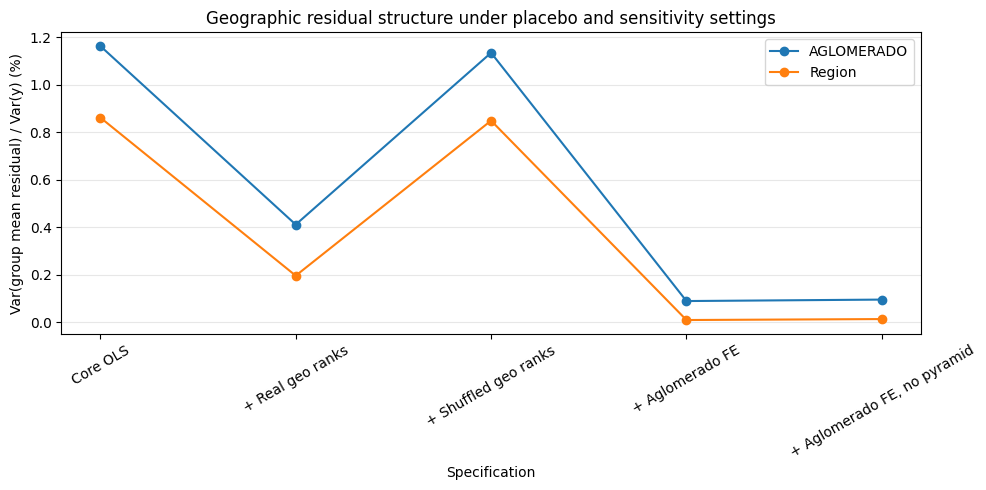

In [9]:

plot_df = geo_variance_decomposition.query("split == 'validation'").copy()

fig, ax = plt.subplots(figsize=(10, 5))
for group_type, tmp in plot_df.groupby("group_type"):
    tmp = tmp.sort_values("experiment_order")
    ax.plot(tmp["label"], tmp["share_var_y_pct"], marker="o", label=group_type)

ax.set_title("Geographic residual structure under placebo and sensitivity settings")
ax.set_xlabel("Specification")
ax.set_ylabel("Var(group mean residual) / Var(y) (%)")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "F5_ols_geo_placebo_variance_share.png", dpi=160)
plt.show()


## 09. Agglomerate FE sensitivity: with vs without pyramid

experiment,ols_core_aglo_fe,ols_core_aglo_fe_no_pyramid,delta_no_pyramid_minus_core_pyramid
count,33.00000,33.00000,33.00000
mean,-0.00385,-0.00359,0.00026
std,0.01278,0.01313,0.00176
min,-0.03577,-0.03667,-0.00578
25%,-0.01068,-0.01029,-0.00042
50%,-0.00240,-0.00083,0.00032
75%,0.00354,0.00440,0.00116
max,0.02604,0.02718,0.00397


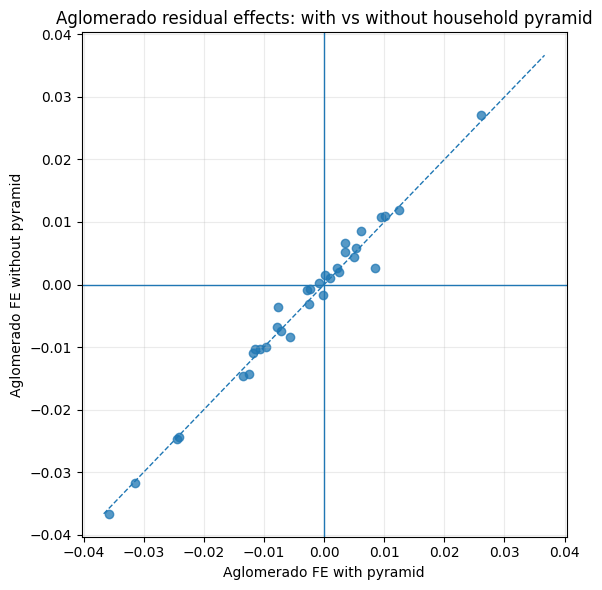

Correlation: 0.9911096172840966


In [10]:

SPLIT = "validation"
MIN_N = 50

df_aglo = (
    group_residuals
    .query("split == @SPLIT and group_type == 'AGLOMERADO' and n >= @MIN_N")
    .copy()
)

compare_exps = ["ols_core_aglo_fe", "ols_core_aglo_fe_no_pyramid"]

df_aglo_wide = (
    df_aglo
    .query("experiment in @compare_exps")
    .pivot_table(
        index="group_value",
        columns="experiment",
        values="mean_residual",
        aggfunc="first",
    )
)

df_aglo_wide["delta_no_pyramid_minus_core_pyramid"] = (
    df_aglo_wide.get("ols_core_aglo_fe_no_pyramid") - df_aglo_wide.get("ols_core_aglo_fe")
)

df_aglo_wide.to_csv(TABLE_DIR / "T7_ols_geo_aglo_fe_pyramid_sensitivity_wide.csv")

display(df_aglo_wide.describe().round(5))

if set(compare_exps).issubset(df_aglo_wide.columns):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(df_aglo_wide["ols_core_aglo_fe"], df_aglo_wide["ols_core_aglo_fe_no_pyramid"], alpha=0.75)

    lim = np.nanmax(np.abs(df_aglo_wide[compare_exps].to_numpy()))
    ax.plot([-lim, lim], [-lim, lim], linestyle="--", linewidth=1)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_title("Aglomerado residual effects: with vs without household pyramid")
    ax.set_xlabel("Aglomerado FE with pyramid")
    ax.set_ylabel("Aglomerado FE without pyramid")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "F6_ols_aglo_fe_with_vs_without_pyramid_scatter.png", dpi=160)
    plt.show()

    corr = df_aglo_wide[compare_exps].corr().iloc[0, 1]
    print("Correlation:", corr)
else:
    print("Missing one of the aglomerado FE sensitivity experiments.")


## 10. Rank features: residual diagnostics by original rank

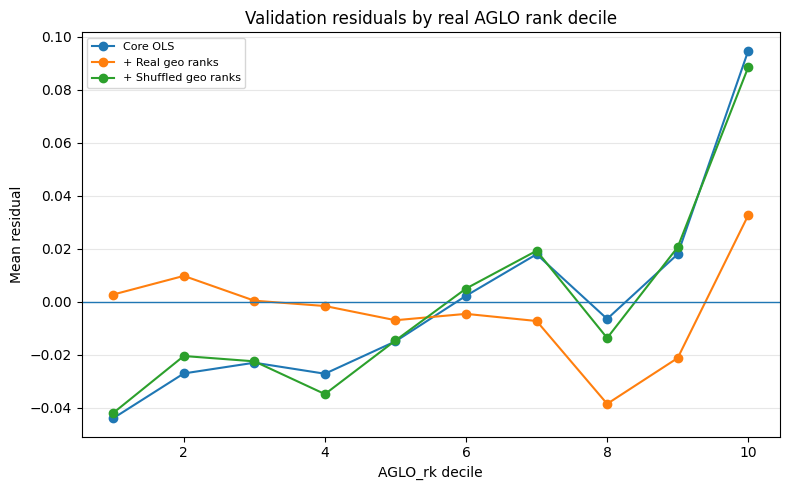

,experiment,AGLO_rk_bin,n,mean_residual,mae,mean_y_true,mean_y_pred
0,ols_core,1,2630,-0.044041,0.194390,3.536910,3.580951
1,ols_core,2,1947,-0.027141,0.221336,3.565184,3.592325
2,ols_core,3,1951,-0.023087,0.218060,3.584246,3.607333
3,ols_core,4,1579,-0.027252,0.222509,3.604129,3.631381
4,ols_core,5,2495,-0.015023,0.216266,3.634773,3.649796


In [11]:

# This section uses original rank columns from the dataset, even for the shuffled-rank run.
# It asks whether residuals are ordered by the real geography rank after fitting.

rank_diag = (
    pred_geo
    .query("split == 'validation' and experiment in ['ols_core', 'ols_core_geo_ranks', 'ols_core_shuffled_geo_ranks']")
    .copy()
)

rank_diag["AGLO_rk_bin"] = pd.qcut(rank_diag["AGLO_rk"], q=10, labels=False, duplicates="drop") + 1
rank_diag["Reg_rk_bin"] = pd.qcut(rank_diag["Reg_rk"], q=5, labels=False, duplicates="drop") + 1

rank_bin_summary = (
    rank_diag
    .groupby(["experiment", "AGLO_rk_bin"], as_index=False)
    .agg(
        n=("row_id", "size"),
        mean_residual=("residual", "mean"),
        mae=("abs_error", "mean"),
        mean_y_true=("y_true", "mean"),
        mean_y_pred=("y_pred", "mean"),
    )
)

rank_bin_summary.to_csv(TABLE_DIR / "T8_ols_geo_rank_bin_residual_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
for experiment in ["ols_core", "ols_core_geo_ranks", "ols_core_shuffled_geo_ranks"]:
    tmp = rank_bin_summary.query("experiment == @experiment").sort_values("AGLO_rk_bin")
    if tmp.empty:
        continue
    ax.plot(tmp["AGLO_rk_bin"], tmp["mean_residual"], marker="o", label=DISPLAY_LABELS.get(experiment, experiment))

ax.axhline(0, linewidth=1)
ax.set_title("Validation residuals by real AGLO rank decile")
ax.set_xlabel("AGLO_rk decile")
ax.set_ylabel("Mean residual")
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "F7_ols_geo_rank_bin_mean_residual.png", dpi=160)
plt.show()

rank_bin_summary.head()


## 11. Top groups affected by pyramid sensitivity

In [12]:

if "delta_no_pyramid_minus_core_pyramid" in df_aglo_wide.columns:
    aglo_delta = (
        df_aglo_wide
        .reset_index()
        .dropna(subset=["delta_no_pyramid_minus_core_pyramid"])
        .assign(abs_delta=lambda d: d["delta_no_pyramid_minus_core_pyramid"].abs())
        .sort_values("abs_delta", ascending=False)
    )

    # Add n and mean_y from one source table.
    aglo_meta = (
        df_aglo
        .query("experiment == 'ols_core_aglo_fe'")
        [["group_value", "n", "mean_y_true"]]
        .drop_duplicates("group_value")
    )
    aglo_delta = aglo_delta.merge(aglo_meta, on="group_value", how="left")

    aglo_delta.to_csv(TABLE_DIR / "T9_ols_geo_top_aglo_pyramid_sensitivity.csv", index=False)
    display(aglo_delta.head(20).round(5))
else:
    print("No aglomerado sensitivity delta available.")


,group_value,ols_core_aglo_fe,ols_core_aglo_fe_no_pyramid,delta_no_pyramid_minus_core_pyramid,abs_delta,n,mean_y_true
0,9,0.00847,0.00269,-0.00578,0.00578,354,3.87646
1,20,-0.00760,-0.00364,0.00397,0.00397,269,3.80515
2,18,0.00345,0.00660,0.00314,0.00314,719,3.54113
3,10,-0.00570,-0.00832,-0.00263,0.00263,736,3.62545
4,8,0.00615,0.00863,0.00248,0.00248,518,3.49937
5,14,-0.00281,-0.00083,0.00198,0.00198,475,3.55830
6,5,-0.00240,-0.00064,0.00175,0.00175,452,3.69699
7,27,-0.01255,-0.01428,-0.00173,0.00173,776,3.59917
8,7,0.00354,0.00518,0.00163,0.00163,430,3.61825
9,30,-0.00015,-0.00162,-0.00147,0.00147,354,3.71051


## 12. Automatic diagnostic summary

In [13]:

def fmt(x, digits=5):
    if pd.isna(x):
        return "NA"
    return f"{x:.{digits}f}"

notes = []
summary = validation_summary.set_index("experiment")

if {"ols_core_geo_ranks", "ols_core_shuffled_geo_ranks"}.issubset(summary.index):
    notes.append(
        "Real vs shuffled geo ranks: "
        f"ΔR²(real-shuffled) = {fmt(summary.loc['ols_core_geo_ranks', 'r2'] - summary.loc['ols_core_shuffled_geo_ranks', 'r2'])}; "
        f"ΔMAE(real-shuffled) = {fmt(summary.loc['ols_core_geo_ranks', 'mae'] - summary.loc['ols_core_shuffled_geo_ranks', 'mae'])}."
    )

if {"ols_core_aglo_fe", "ols_core_aglo_fe_no_pyramid"}.issubset(summary.index):
    notes.append(
        "Aglomerado FE pyramid sensitivity: "
        f"ΔR²(with pyramid - no pyramid) = {fmt(summary.loc['ols_core_aglo_fe', 'r2'] - summary.loc['ols_core_aglo_fe_no_pyramid', 'r2'])}; "
        f"ΔMAE(with pyramid - no pyramid) = {fmt(summary.loc['ols_core_aglo_fe', 'mae'] - summary.loc['ols_core_aglo_fe_no_pyramid', 'mae'])}."
    )

v = geo_variance_decomposition.query("split == 'validation' and group_type == 'AGLOMERADO'")
for exp in ["ols_core_geo_ranks", "ols_core_shuffled_geo_ranks", "ols_core_aglo_fe", "ols_core_aglo_fe_no_pyramid"]:
    row = v.query("experiment == @exp")
    if not row.empty:
        row = row.iloc[0]
        notes.append(
            f"{exp} / AGLOMERADO: sd(group mean residual) = {fmt(row['sd_group_mean_residual'])}; "
            f"share Var(y) = {fmt(row['share_var_y_pct'])}%."
        )

if set(compare_exps).issubset(df_aglo_wide.columns):
    corr = df_aglo_wide[compare_exps].corr().iloc[0, 1]
    notes.append(
        f"Aglomerado residual-effect correlation with vs without household pyramid = {fmt(corr)}."
    )

DIAGNOSTIC_SUMMARY = "\n".join(f"- {note}" for note in notes)
print(DIAGNOSTIC_SUMMARY)

(TABLE_DIR / "T10_ols_geo_placebo_diagnostic_notes.txt").write_text(DIAGNOSTIC_SUMMARY, encoding="utf-8")


- Real vs shuffled geo ranks: ΔR²(real-shuffled) = 0.01032; ΔMAE(real-shuffled) = -0.00244.
- Aglomerado FE pyramid sensitivity: ΔR²(with pyramid - no pyramid) = 0.00875; ΔMAE(with pyramid - no pyramid) = -0.00180.
- ols_core_geo_ranks / AGLOMERADO: sd(group mean residual) = 0.02419; share Var(y) = 0.41065%.
- ols_core_shuffled_geo_ranks / AGLOMERADO: sd(group mean residual) = 0.04019; share Var(y) = 1.13365%.
- ols_core_aglo_fe / AGLOMERADO: sd(group mean residual) = 0.01125; share Var(y) = 0.08888%.
- ols_core_aglo_fe_no_pyramid / AGLOMERADO: sd(group mean residual) = 0.01163; share Var(y) = 0.09499%.
- Aglomerado residual-effect correlation with vs without household pyramid = 0.99111.


696


## 13. Outputs written

Tables:

```text
reports/notebook_outputs/ols_geo_placebos_and_sensitivity/tables/
```

Figures:

```text
reports/notebook_outputs/ols_geo_placebos_and_sensitivity/figures/
```

Key thesis candidates:

```text
T2_ols_geo_placebo_validation_summary.csv
T3_ols_geo_placebo_pairwise_checks.csv
T6_ols_geo_placebo_variance_decomposition.csv
T7_ols_geo_aglo_fe_pyramid_sensitivity_wide.csv
F1_ols_geo_ranks_real_vs_shuffled_delta_r2.png
F3_ols_aglo_fe_no_pyramid_delta_r2.png
F5_ols_geo_placebo_variance_share.png
F6_ols_aglo_fe_with_vs_without_pyramid_scatter.png
F7_ols_geo_rank_bin_mean_residual.png
```
